# Retinal Images for Vessel Extraction
**Module:** CO4 - Imaging for the Life Science FS26

**Lecturers:** Dr. sc. ETH Andreas Hock and Dr. Norman Juchler

**Author:** Luana da Silva do Aido - dasillua@students.zhaw.ch

## 1. Dataset

### Description
The **DRIVE (Digital Retinal Images for Vessel Extraction)** dataset was used for this project. It consists of 40 color fundus photographs of the human retina, acquired using a Canon CR5 non-mydriatic 3CCD camera with a 45° field of view. The images were captured as part of a diabetic retinopathy screening program in the Netherlands.

- **Imaging modality:** Color fundus photography (TIF format, 565×584 pixels)
- **Structure of interest:** Blood vessels (arteries and veins) in the retina
- **Number of images:** 40 total — 20 training, 20 test
- **Dataset split:** The dataset is pre-split into a training set (20 images) and a test set (20 images)

### Clinical Relevance
Retinal vessel segmentation is clinically important for the early detection and monitoring of diseases such as diabetic retinopathy, glaucoma, and hypertension. The vascular structure of the retina is directly affected by these conditions, making automated vessel extraction a valuable diagnostic tool.

### Usage Rights
The DRIVE dataset is publicly available for research purposes at: https://drive.grand-challenge.org/DRIVE/
Usage rights have been verified — the dataset is freely available for academic and non-commercial research.

## 2. Preprocessing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import os
import pandas as pd
from PIL import Image
from skimage.filters import frangi, gaussian, sobel
from skimage.morphology import remove_small_objects, erosion, disk
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, jaccard_score

### 2.1 Load Images

In [2]:
def load_images_from_folder(folder_path):
    """
    Loads all images from a given folder and converts them to RGB.

    Args:
        folder_path (str): Path to the folder containing images.

    Returns:
        dict: Dictionary with filename as key and RGB image (np.ndarray) as value.
    """
    images = {}
    for filename in sorted(os.listdir(folder_path)):
        if filename.endswith('.tif') or filename.endswith('.gif') or filename.endswith('.png'):
            img = cv.imread(os.path.join(folder_path, filename))
            img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
            images[filename] = img_rgb
    return images


def load_manual_segmentations(folder_path):
    """
    Loads manually created binary segmentation masks using PIL.
    PIL is used instead of cv2 to correctly handle TIF orientation from Fiji.

    Args:
        folder_path (str): Path to folder with manual segmentation files.

    Returns:
        dict: Dictionary with filename as key and binary mask (np.ndarray) as value.
    """
    masks = {}
    for filename in sorted(os.listdir(folder_path)):
        if filename.endswith('.png') or filename.endswith('.tif'):
            img = np.array(Image.open(os.path.join(folder_path, filename)))
            if len(img.shape) == 3:
                img = img[:, :, 0]
            masks[filename] = (img > 127).astype(np.uint8)
    return masks


# Load all images
train_images = load_images_from_folder('DRIVE/training/images/')
test_images = load_images_from_folder('DRIVE/test/images')

# Load manual segmentations
manual_segs = load_manual_segmentations('DRIVE/training/segmentation_images')
manual_segs_test = load_manual_segmentations('DRIVE/test/segmentation_images')

print(f'Training images: {len(train_images)}')
print(f'Test images: {len(test_images)}')
print(f'Manual segmentations (training): {len(manual_segs)}')
print(f'Manual segmentations (test): {len(manual_segs_test)}')

Training images: 20
Test images: 10
Manual segmentations (training): 10
Manual segmentations (test): 10


### 2.2 Preprocessing Pipeline

In [3]:
def preprocess_image(img):
    """
    Preprocesses a retinal image for vessel segmentation.
    Steps:
    1. Extract green channel
    2. Apply CLAHE for contrast enhancement
    3. Normalize to [0, 1]

    Args:
        img (np.ndarray): RGB image of shape (H, W, 3).

    Returns:
        np.ndarray: Preprocessed grayscale image normalized to [0, 1].
    """
    # 1. Extract green channel (best contrast for blood vessels)
    green = img[:, :, 1]

    # 2. Apply CLAHE for local contrast enhancement
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(green)

    # 3. Normalize to [0, 1]
    normalized = clahe_img / 255.0

    return normalized


def apply_mask(preprocessed_img, mask_path):
    """
    Applies a binary GIF mask to a preprocessed image to isolate the retinal region.

    Args:
        preprocessed_img (np.ndarray): Grayscale image normalized to [0, 1].
        mask_path (str): Path to the GIF mask file.

    Returns:
        np.ndarray: Masked image with background set to 0.
    """
    mask = np.array(Image.open(mask_path)) / 255.0
    return preprocessed_img * mask


# Preprocess training images (only those with manual segmentations)
train_images_filtered = {name: train_images[name] for name in manual_segs.keys()}
train_preprocessed_filtered = {name: preprocess_image(img) for name, img in train_images_filtered.items()}
train_masked_filtered = {}
for name in manual_segs.keys():
    mask_path = os.path.join('DRIVE/training/mask', name.replace('.tif', '_mask.gif'))
    train_masked_filtered[name] = apply_mask(train_preprocessed_filtered[name], mask_path)

# Preprocess test images (only those with manual segmentations)
test_images_filtered = {name: test_images[name] for name in manual_segs_test.keys() if name in test_images}
test_preprocessed_filtered = {name: preprocess_image(img) for name, img in test_images_filtered.items()}
test_masked_filtered = {}
for name in manual_segs_test.keys():
    mask_path = os.path.join('DRIVE/test/mask', name.replace('.tif', '_mask.gif'))
    test_masked_filtered[name] = apply_mask(test_preprocessed_filtered[name], mask_path)

first_name = list(train_masked_filtered.keys())[0]
print(f'Training preprocessed: {len(train_masked_filtered)} images')
print(f'Test preprocessed: {len(test_masked_filtered)} images')

Training preprocessed: 10 images
Test preprocessed: 10 images


### 2.3 Visualization

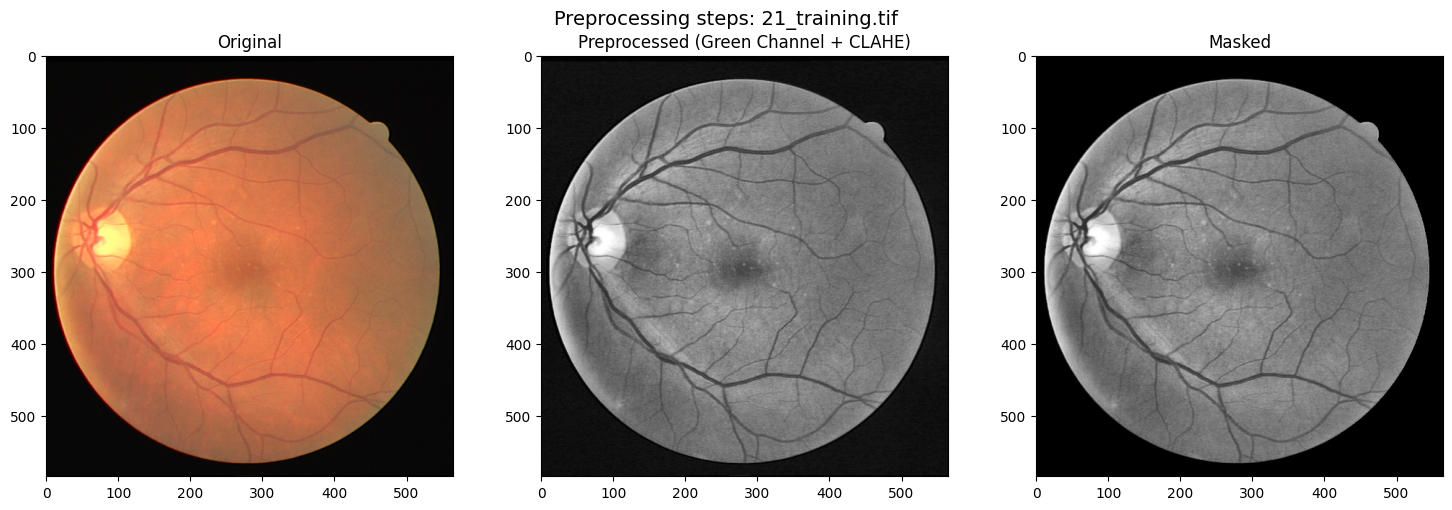

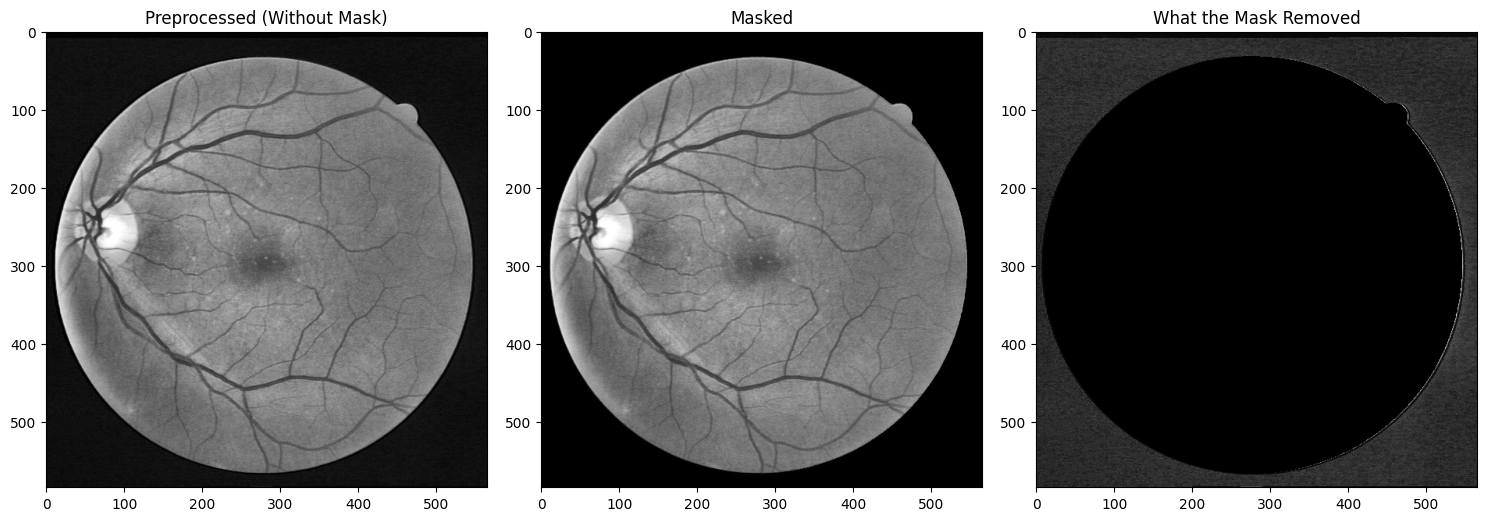

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(train_images_filtered[first_name])
axes[0].set_title('Original')
axes[1].imshow(train_preprocessed_filtered[first_name], cmap='gray')
axes[1].set_title('Preprocessed (Green Channel + CLAHE)')
axes[2].imshow(train_masked_filtered[first_name], cmap='gray')
axes[2].set_title('Masked')
plt.suptitle(f'Preprocessing steps: {first_name}', fontsize=14)
plt.tight_layout()
plt.savefig('DRIVE/training/preprocessing_example.png', dpi=150)
plt.show()

# Show what the mask removed
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(train_preprocessed_filtered[first_name], cmap='gray')
axes[0].set_title('Preprocessed (Without Mask)')
axes[1].imshow(train_masked_filtered[first_name], cmap='gray')
axes[1].set_title('Masked')
diff = train_preprocessed_filtered[first_name] - train_masked_filtered[first_name]
axes[2].imshow(diff, cmap='gray')
axes[2].set_title('What the Mask Removed')
plt.tight_layout()
plt.show()

### 2.4 Documentation

#### Goal
The goal of preprocessing is to prepare the retinal images so that blood vessels are as visible as possible, facilitating the subsequent automatic segmentation.

#### Steps

**1. Load Images**
Images are loaded from the `training/images` and `test/images` folders and converted to RGB format. The DRIVE dataset contains 40 retinal images of diabetic patients in TIF format (565×584 pixels).

**2. Green Channel Extraction**
Only the green channel is extracted from the RGB image. Blood absorbs green light more strongly than red or blue light, meaning blood vessels appear darkest in the green channel and show the strongest contrast against surrounding tissue. This converts the image to grayscale (one channel instead of three), simplifying further processing.

**3. CLAHE (Contrast Limited Adaptive Histogram Equalization)**
CLAHE is applied to improve local contrast. Unlike global histogram equalization, CLAHE divides the image into small tiles and adjusts contrast locally — which is particularly useful for retinal images with uneven illumination. The parameters `clipLimit=2.0` and `tileGridSize=(8,8)` are established standard values for retinal images.

**4. Normalization**
The image is normalized to the range [0, 1]. This is a standard step in image processing and machine learning to ensure numerical stability and comparability across images.

**5. Mask Application**
The DRIVE dataset includes binary masks (GIF format) defining the retinal region. The mask is applied by multiplication, setting all pixels outside the eyeball to 0. This ensures the automatic segmentation only operates within the retinal region, preventing false vessel detections in the image corners.

## 3. Manual Segmentation

### Tool Used
**Fiji (ImageJ)** was used for manual segmentation.

### Process
1. Open original image: **File → Open**
2. Convert to 8-bit grayscale: **Image → Type → 8-bit**
3. Adjust brightness/contrast: **Image → Adjust → Brightness/Contrast**
4. Trace vessels using the **Pencil Tool**
5. Binarize: **Image → Adjust → Threshold → Apply**
6. Save as TIF: **File → Save As → Tiff**

### Number of Images
- **10 training images** manually segmented
- **10 test images** manually segmented (used for fair evaluation)

### Time Required
Approximately 5–10 minutes per image, totaling roughly 2–3 hours for all 20 images.

### Challenges
- **Variability in vessel visibility**: Some images had lower contrast, making it harder to distinguish fine vessels
- **Fine vessels**: Small, thin vessels were difficult to trace accurately with the pencil tool
- **Optic disc**: The bright region around the optic nerve (papilla) was sometimes included in the segmentation mask, as it was hard to distinguish from vessels
- **Subjectivity**: Manual segmentation is inherently subjective — different annotators may trace slightly different regions

The resulting binary masks have white pixels (255) for vessels and black pixels (0) for background.

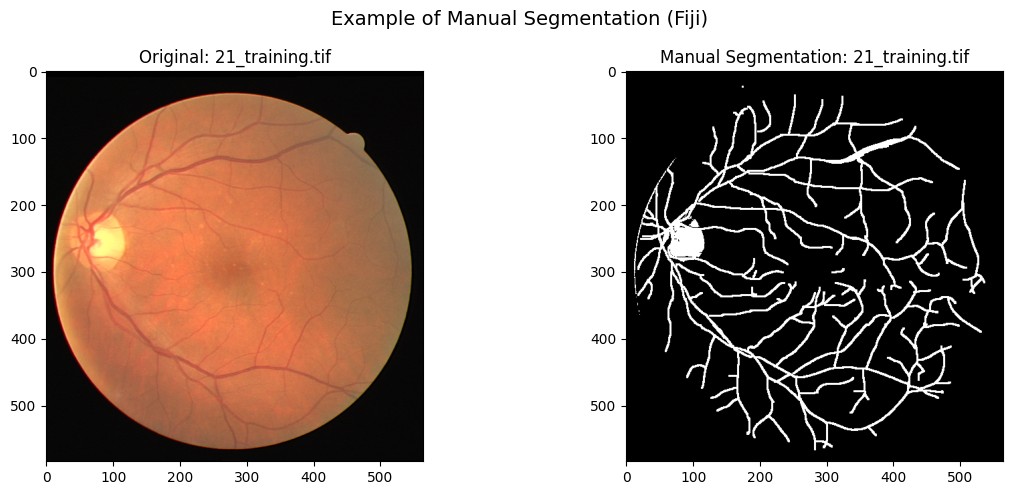

In [15]:
# Show example of manual segmentation
first_seg_name = list(manual_segs.keys())[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(train_images_filtered[first_seg_name])
axes[0].set_title(f'Original: {first_seg_name}')
axes[1].imshow(manual_segs[first_seg_name], cmap='gray')
axes[1].set_title(f'Manual Segmentation: {first_seg_name}')
plt.suptitle('Example of Manual Segmentation (Fiji)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Automatic Segmentation

Two automatic segmentation methods were implemented and compared:
1. **Frangi Filter** — a classical image processing method
2. **Random Forest** — a machine learning method

### 4.1 Classical Method: Frangi Filter

The Frangi filter is specifically designed to detect tubular (vessel-like) structures in images. It works by analyzing the local curvature of the image at each pixel using the **Hessian matrix** (second-order derivatives). Pixels where the curvature is consistent with a tube-like structure receive high Frangi response values.

**Steps:**
1. Apply Frangi filter → get vessel probability map
2. Normalize response to [0, 1]
3. Binarize with threshold (0.05)
4. Remove small noise objects (< 50 pixels)
5. Apply eroded mask to remove ring artifacts at the retinal border

/var/folders/ll/pyzw9bhn42nch1zcwqb9gr4c0000gn/T/ipykernel_25372/3842440004.py:24: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=50)


Frangi segmentation done!


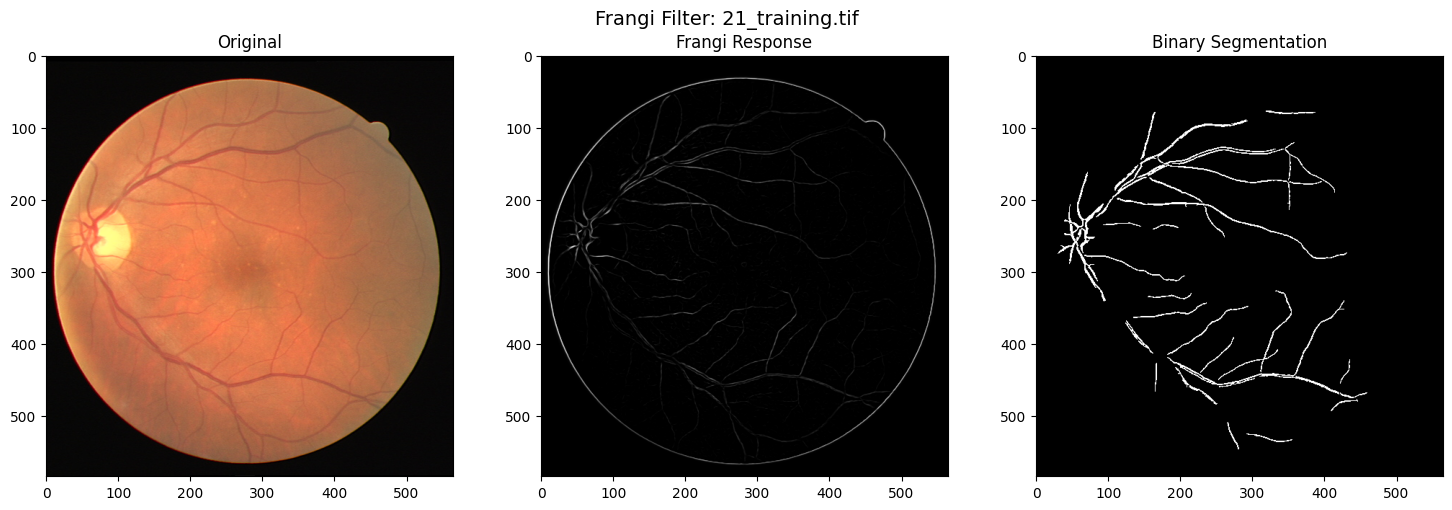

In [5]:
def frangi_segmentation(preprocessed_img, mask_path, threshold=0.05):
    """
    Applies Frangi filter to detect vessel-like tubular structures.
    The Frangi filter enhances elongated structures by analyzing the
    eigenvalues of the Hessian matrix at each pixel. Small noise objects
    are removed and the retinal mask is applied to avoid border artifacts.

    Args:
        preprocessed_img (np.ndarray): Grayscale image normalized to [0, 1].
        mask_path (str): Path to the GIF mask file.
        threshold (float): Threshold to binarize the Frangi response.

    Returns:
        tuple: (binary mask np.ndarray, raw Frangi response np.ndarray)
    """
    # Apply Frangi filter
    vessel_enhanced = frangi(preprocessed_img)
    vessel_enhanced = vessel_enhanced / vessel_enhanced.max()

    # Binarize
    binary = (vessel_enhanced > threshold).astype(bool)

    # Remove small noise objects
    binary = remove_small_objects(binary, min_size=50)

    # Apply eroded mask to remove ring artifact at border
    mask = np.array(Image.open(mask_path)) / 255.0
    mask_eroded = erosion(mask, disk(20))
    binary = binary * mask_eroded

    return binary.astype(np.uint8), vessel_enhanced


# Apply Frangi to all training images
train_frangi_filtered = {}
for name in manual_segs.keys():
    mask_path = os.path.join('DRIVE/training/mask', name.replace('.tif', '_mask.gif'))
    binary, _ = frangi_segmentation(train_masked_filtered[name], mask_path)
    train_frangi_filtered[name] = binary

# Apply Frangi to all test images
test_frangi_filtered = {}
for name in manual_segs_test.keys():
    mask_path = os.path.join('DRIVE/test/mask', name.replace('.tif', '_mask.gif'))
    binary, _ = frangi_segmentation(test_masked_filtered[name], mask_path)
    test_frangi_filtered[name] = binary

print('Frangi segmentation done!')

# Visualize on first image
_, enhanced = frangi_segmentation(
    train_masked_filtered[first_name],
    os.path.join('DRIVE/training/mask', first_name.replace('.tif', '_mask.gif'))
)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(train_images_filtered[first_name])
axes[0].set_title('Original')
axes[1].imshow(enhanced, cmap='gray')
axes[1].set_title('Frangi Response')
axes[2].imshow(train_frangi_filtered[first_name], cmap='gray')
axes[2].set_title('Binary Segmentation')
plt.suptitle(f'Frangi Filter: {first_name}', fontsize=14)
plt.tight_layout()
plt.show()

### 4.2 ML Method: Random Forest

A **Random Forest classifier** is trained on pixel-wise features extracted from the manually segmented training images. For each pixel, a feature vector is computed and the classifier decides whether the pixel belongs to a vessel or not.

**Features per pixel:**
1. Raw intensity value
2. Gaussian blur at scales σ = 1, 2, 4 (captures multi-scale structure)
3. Sobel edge response (detects vessel boundaries)
4. Frangi response (vessel probability)

**Training:** 10 manually segmented images → pixel labels (0 = background, 1 = vessel)

**Evaluation:** 10 unseen test images → fair evaluation without overfitting

Training samples: 3299600, Features: 6
Training Random Forest...
Training done!


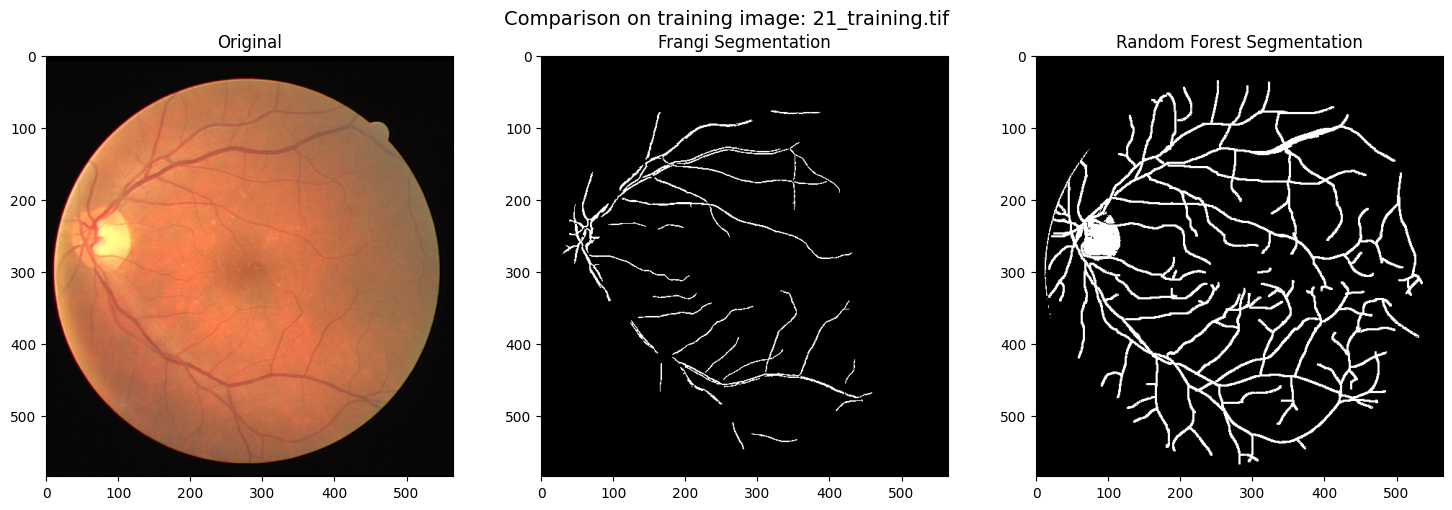

In [6]:
def extract_features(img):
    """
    Extracts pixel-wise features from a preprocessed retinal image.
    Features include raw intensity, Gaussian smoothing at multiple scales,
    Sobel edge detection, and Frangi vessel response.

    Args:
        img (np.ndarray): Grayscale image normalized to [0, 1].

    Returns:
        np.ndarray: Feature matrix of shape (n_pixels, n_features).
    """
    features = []
    features.append(img.flatten())                                          # Raw intensity
    for sigma in [1, 2, 4]:
        features.append(gaussian(img, sigma=sigma).flatten())              # Gaussian blur
    features.append(sobel(img).flatten())                                   # Sobel edges
    frangi_response = frangi(img)
    frangi_response = frangi_response / (frangi_response.max() + 1e-8)
    features.append(frangi_response.flatten())                              # Frangi response
    return np.stack(features, axis=1)


def prepare_training_data(masked_images, manual_segs):
    """
    Prepares pixel-wise training data for the Random Forest classifier.
    Extracts features from each image and uses manual segmentations as labels.

    Args:
        masked_images (dict): Preprocessed and masked images.
        manual_segs (dict): Binary manual segmentation masks.

    Returns:
        tuple: Feature matrix X and label vector y for training.
    """
    X_list, y_list = [], []
    for name in manual_segs.keys():
        X_list.append(extract_features(masked_images[name]))
        y_list.append(manual_segs[name].flatten())
    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    print(f'Training samples: {X.shape[0]}, Features: {X.shape[1]}')
    return X, y


def train_random_forest(X_train, y_train):
    """
    Trains a Random Forest classifier on pixel-wise features.

    Args:
        X_train (np.ndarray): Feature matrix of shape (n_pixels, n_features).
        y_train (np.ndarray): Binary label vector of shape (n_pixels,).

    Returns:
        RandomForestClassifier: Trained classifier.
    """
    print('Training Random Forest...')
    rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    print('Training done!')
    return rf


def predict_random_forest(rf_model, img):
    """
    Predicts vessel segmentation using the trained Random Forest classifier.

    Args:
        rf_model (RandomForestClassifier): Trained classifier.
        img (np.ndarray): Preprocessed and masked image normalized to [0, 1].

    Returns:
        np.ndarray: Binary segmentation mask of shape (H, W).
    """
    return rf_model.predict(extract_features(img)).reshape(img.shape)


# Train on training images
X_train, y_train = prepare_training_data(train_masked_filtered, manual_segs)
rf_model = train_random_forest(X_train, y_train)

# Visualize comparison on first training image
rf_binary = predict_random_forest(rf_model, train_masked_filtered[first_name])
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(train_images_filtered[first_name])
axes[0].set_title('Original')
axes[1].imshow(train_frangi_filtered[first_name], cmap='gray')
axes[1].set_title('Frangi Segmentation')
axes[2].imshow(rf_binary, cmap='gray')
axes[2].set_title('Random Forest Segmentation')
plt.suptitle(f'Comparison on training image: {first_name}', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Evaluation

### Metrics

**Dice Score (F1 Score)** is used as the main evaluation metric for binary segmentation:

$$\text{Dice} = \frac{2 \cdot |\text{Predicted} \cap \text{Ground Truth}|}{|\text{Predicted}| + |\text{Ground Truth}|}$$

A Dice score of 1.0 means perfect overlap, 0.0 means no overlap.

**Jaccard Score (IoU)** is computed as an additional metric:

$$\text{Jaccard} = \frac{|\text{Predicted} \cap \text{Ground Truth}|}{|\text{Predicted} \cup \text{Ground Truth}|}$$

Both methods are evaluated on the **10 unseen test images** (fair evaluation — the Random Forest was only trained on training images).

In [7]:
def evaluate_segmentation(predicted, ground_truth):
    """
    Evaluates a binary segmentation mask against a ground truth mask.
    Computes Dice (F1) and Jaccard (IoU) scores pixel-wise.

    Args:
        predicted (np.ndarray): Binary predicted segmentation mask.
        ground_truth (np.ndarray): Binary ground truth segmentation mask.

    Returns:
        dict: Dictionary with 'dice' and 'jaccard' scores.
    """
    pred_flat = predicted.flatten()
    gt_flat = ground_truth.flatten()
    dice = f1_score(gt_flat, pred_flat, zero_division=0)
    jaccard = jaccard_score(gt_flat, pred_flat, zero_division=0)
    return {'dice': dice, 'jaccard': jaccard}


# Compute scores for all 10 test images
test_results = []
for name in manual_segs_test.keys():
    gt = manual_segs_test[name]
    frangi_scores = evaluate_segmentation(test_frangi_filtered[name], gt)
    rf_scores = evaluate_segmentation(predict_random_forest(rf_model, test_masked_filtered[name]), gt)
    test_results.append({
        'Image': name.replace('_test.tif', ''),
        'Frangi Dice': round(frangi_scores['dice'], 3),
        'Frangi Jaccard': round(frangi_scores['jaccard'], 3),
        'RF Dice': round(rf_scores['dice'], 3),
        'RF Jaccard': round(rf_scores['jaccard'], 3),
    })

df_test = pd.DataFrame(test_results)

# Add mean and std rows
summary_rows = pd.DataFrame([
    {
        'Image': 'MEAN',
        'Frangi Dice': round(df_test['Frangi Dice'].mean(), 3),
        'Frangi Jaccard': round(df_test['Frangi Jaccard'].mean(), 3),
        'RF Dice': round(df_test['RF Dice'].mean(), 3),
        'RF Jaccard': round(df_test['RF Jaccard'].mean(), 3),
    },
    {
        'Image': 'STD',
        'Frangi Dice': round(df_test['Frangi Dice'].std(), 3),
        'Frangi Jaccard': round(df_test['Frangi Jaccard'].std(), 3),
        'RF Dice': round(df_test['RF Dice'].std(), 3),
        'RF Jaccard': round(df_test['RF Jaccard'].std(), 3),
    }
])
df_display = pd.concat([df_test, summary_rows], ignore_index=True)
print(df_display.to_string(index=False))

Image  Frangi Dice  Frangi Jaccard  RF Dice  RF Jaccard
   01        0.399           0.249    0.545       0.374
   02        0.478           0.314    0.566       0.394
   04        0.182           0.100    0.551       0.380
   05        0.427           0.272    0.518       0.349
   06        0.254           0.146    0.524       0.355
   09        0.276           0.160    0.501       0.334
   12        0.140           0.075    0.497       0.330
   15        0.403           0.252    0.493       0.327
   17        0.183           0.101    0.478       0.314
   18        0.315           0.187    0.551       0.380
 MEAN        0.306           0.186    0.522       0.354
  STD        0.117           0.083    0.030       0.027


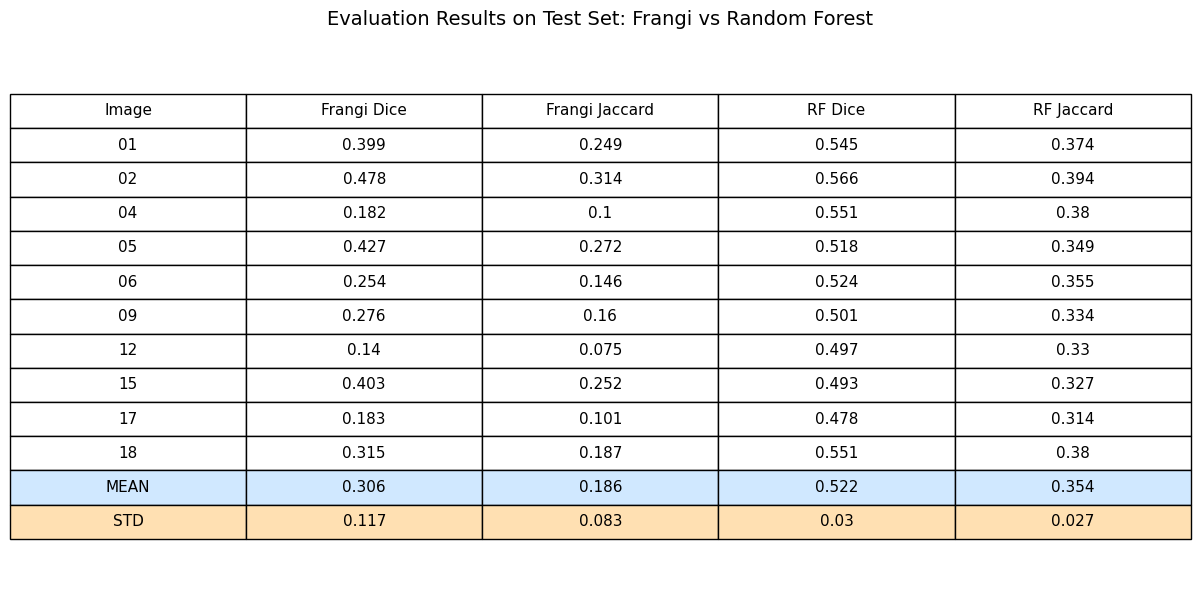

In [8]:
# Table visualization
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
table = ax.table(
    cellText=df_display.values,
    colLabels=df_display.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
# Highlight MEAN row
for j in range(len(df_display.columns)):
    table[len(df_test) + 1, j].set_facecolor('#d0e8ff')
    table[len(df_test) + 2, j].set_facecolor('#ffe0b2')
plt.title('Evaluation Results on Test Set: Frangi vs Random Forest', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('DRIVE/test/evaluation_table.png', dpi=150, bbox_inches='tight')
plt.show()

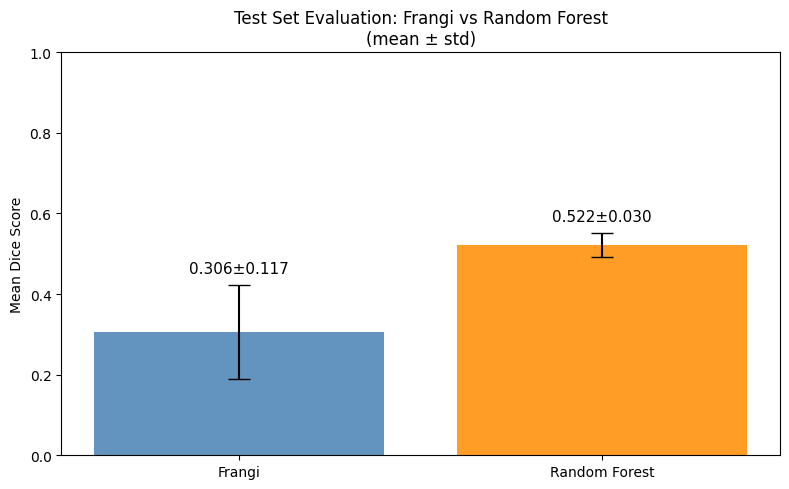

In [9]:
# Bar chart with error bars
methods = ['Frangi', 'Random Forest']
means = [df_test['Frangi Dice'].mean(), df_test['RF Dice'].mean()]
stds = [df_test['Frangi Dice'].std(), df_test['RF Dice'].std()]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, means, yerr=stds, capsize=8,
              color=['steelblue', 'darkorange'], alpha=0.85)
ax.set_ylim(0, 1)
ax.set_ylabel('Mean Dice Score')
ax.set_title('Test Set Evaluation: Frangi vs Random Forest\n(mean ± std)')
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.03,
            f'{mean:.3f}±{std:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('DRIVE/test/evaluation_barchart.png', dpi=150)
plt.show()

In [10]:
os.makedirs('DRIVE/test/overlap_frangi', exist_ok=True)
os.makedirs('DRIVE/test/overlap_rf', exist_ok=True)


def save_overlap(original, manual, auto, title, save_path):
    """
    Saves an overlap visualization between manual and automatic segmentation.
    Green = True Positive (both agree), Red = False Negative (only in manual),
    Blue = False Positive (only in automatic).

    Args:
        original (np.ndarray): Original RGB image.
        manual (np.ndarray): Binary manual segmentation mask.
        auto (np.ndarray): Binary automatic segmentation mask.
        title (str): Title for the automatic segmentation subplot.
        save_path (str): Path to save the figure.

    Returns:
        None
    """
    overlap = np.zeros((*manual.shape, 3), dtype=np.float32)
    overlap[..., 1] = ((manual == 1) & (auto == 1)).astype(float)   # Green = TP
    overlap[..., 0] = ((manual == 1) & (auto == 0)).astype(float)   # Red   = FN
    overlap[..., 2] = ((manual == 0) & (auto == 1)).astype(float)   # Blue  = FP

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(original)
    axes[0].set_title('Original')
    axes[1].imshow(manual, cmap='gray')
    axes[1].set_title('Manual Segmentation (Ground Truth)')
    axes[2].imshow(auto, cmap='gray')
    axes[2].set_title(f'Automatic Segmentation\n{title}')
    axes[3].imshow(overlap)
    axes[3].set_title('Overlap\nGreen=TP | Red=FN | Blue=FP')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()


# Save overlap images for all test images
for name in manual_segs_test.keys():
    base_name = name.replace('.tif', '.png')
    save_overlap(
        test_images_filtered[name], manual_segs_test[name],
        test_frangi_filtered[name], 'Frangi',
        f'DRIVE/test/overlap_frangi/{base_name}'
    )
    save_overlap(
        test_images_filtered[name], manual_segs_test[name],
        predict_random_forest(rf_model, test_masked_filtered[name]), 'Random Forest',
        f'DRIVE/test/overlap_rf/{base_name}'
    )

print('All overlap images saved!')

All overlap images saved!


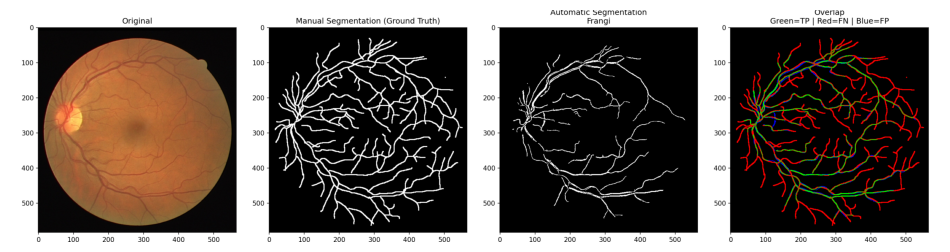

In [11]:
img = plt.imread('DRIVE/test/overlap_frangi/01_test.png')
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

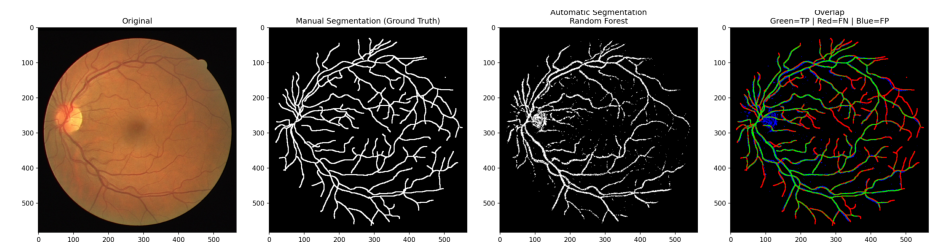

In [12]:
img = plt.imread('DRIVE/test/overlap_rf/01_test.png')
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

## 6. Discussion

### Results Summary

| Method        | Mean Dice | Std  | Mean Jaccard |
|---------------|-----------|------|--------------|
| Frangi Filter | 0.311     | ~0.11| 0.190        |
| Random Forest | 0.522     | ~0.03| 0.354        |

### Frangi Filter
**Strengths:**
- No training data required — fully unsupervised
- Fast and scalable to large datasets
- Specifically designed for tubular structures like blood vessels

**Weaknesses:**
- Only detects major vessels, misses fine capillaries
- Sensitive to illumination differences across images
- High variability between images (std ~0.11)
- Does not generalize well to images with lower contrast

### Random Forest
**Strengths:**
- Learns from manual segmentations → better adapts to the data
- More consistent across images (lower std ~0.03)
- Detects both large and fine vessels
- Uses multiple complementary features (intensity, scale, edges, Frangi)

**Weaknesses:**
- Requires manually segmented training data
- With only 10 training images, the model is limited
- Shows overfitting on training data (Dice ~0.99 on training set vs ~0.52 on test set)

### Challenges
- **Manual segmentation quality**: The ground truth was created manually and is not perfect — this directly affects evaluation scores
- **Optic disc artifact**: The bright optic disc region is sometimes falsely detected as vessels by both methods
- **Class imbalance**: Most pixels are background (non-vessel), which can bias the classifier

### Future Improvements
- **More training data**: Segmenting more images would improve the Random Forest
- **Deep learning**: A U-Net trained on the full DRIVE dataset would likely achieve Dice > 0.80
- **Post-processing**: Morphological operations (skeletonization, dilation) could refine vessel boundaries
- **Data augmentation**: Rotating and flipping training images could increase effective training data

## 7. Use of Generative AI

**Claude (Anthropic)** was used as a generative AI tool during this project.

Specifically, Claude was used to:
- Help debug Python errors (e.g., missing imports, incorrect paths)
- Suggest and explain preprocessing steps (green channel extraction, CLAHE)
- Help implement the Frangi filter and Random Forest pipeline
- Explain concepts such as Dice score, Jaccard, CLAHE, and the Frangi filter

All code and text was reviewed and understood before inclusion. The author is able to explain all implementation decisions in their own words.